# PRT661 — Univariate Analysis
**Md Adnan Abir (s382198) · Group Dan3 · Theme 2**


# Uploading cleaned Data

In [ ]:
import os

CSV_NAME = "Cleaned_data_final.csv"

if not os.path.exists(CSV_NAME):
    from google.colab import files
    uploaded = files.upload()
    picked = list(uploaded.keys())[0]
    if picked != CSV_NAME:
        os.rename(picked, CSV_NAME)

print("CSV ready:", os.path.exists(CSV_NAME))

Saving Cleaned_data_final.csv to Cleaned_data_final.csv
CSV ready: True


# Analysis

In [ ]:

from __future__ import annotations

import json
import os
from typing import Dict, List

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuration

INDEX_COL = "Unnamed: 0"

DEMOGRAPHIC_KEYS = [
    "Country of birth of person",
    "Language used at home",
    "Years spent in Australia",
    "Age group",
    "Sex",
]

CATEGORICAL_LOW = [
    "Years spent in Australia",
    "Age group",
    "Sex",
    "Long-term health condition (LTHC)",
    "Proficiency in spoken English",
    "Region_class",
]

CATEGORICAL_HIGH = [
    "Country of birth of person",
    "Language used at home",
    "Subregion_class",
]

NUMERIC = [
    "Number of people reporting LTHC(s)",
    "Population",
    "Age-specific percentage of population reporting LTHC(s)",
]

# Short, filesystem-safe names for figure files.
SHORT_NAME = {
    "Years spent in Australia": "years_in_australia",
    "Age group": "age_group",
    "Sex": "sex",
    "Long-term health condition (LTHC)": "lthc",
    "Proficiency in spoken English": "english_proficiency",
    "Region_class": "region",
    "Country of birth of person": "country",
    "Language used at home": "language",
    "Subregion_class": "subregion",
    "Number of people reporting LTHC(s)": "num_reporting",
    "Population": "population",
    "Age-specific percentage of population reporting LTHC(s)": "pct_reporting",
}



# Loading & structure


def load_data(path: str) -> pd.DataFrame:
    """Load the cleaned CSV and drop the exported index column."""
    df = pd.read_csv(path)
    if INDEX_COL in df.columns:
        df = df.drop(columns=[INDEX_COL])
    return df


def summarise_structure(df: pd.DataFrame) -> Dict:
    populated = df["Population"] > 0
    return {
        "n_rows": int(df.shape[0]),
        "n_cols": int(df.shape[1]),
        "total_missing": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "populated_rows": int(populated.sum()),
        "empty_cell_pct": round((~populated).mean() * 100, 2),
        "count_zero_but_pop_positive": int(((df["Number of people reporting LTHC(s)"] == 0) & populated).sum()),
        "dtypes": {c: str(t) for c, t in df.dtypes.items()},
    }


def populated_subset(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["Population"] > 0].copy()


def demographic_population(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates(subset=DEMOGRAPHIC_KEYS).copy()


# Categorical analysis

def analyse_categorical(df: pd.DataFrame, col: str, out_dir: str) -> Dict:
    """Frequency table + bar chart for a low-cardinality categorical column."""
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    counts.sort_values().plot(kind="barh", ax=ax, color="#2E5A88")
    ax.set_title(f"Distribution of '{col}'")
    ax.set_xlabel("Count of rows")
    ax.set_ylabel("")
    fig.tight_layout()
    fig_path = os.path.join(out_dir, f"cat_{SHORT_NAME[col]}.png")
    fig.savefig(fig_path, dpi=120)
    plt.close(fig)

    return {
        "n_unique": int(df[col].nunique(dropna=False)),
        "counts": counts.to_dict(),
        "percentages": pct.to_dict(),
        "mode": counts.index[0],
        "figure": fig_path,
    }


def analyse_categorical_weighted(df: pd.DataFrame, col: str, out_dir: str,
                                 top_n: int = 10) -> Dict:
    cells = demographic_population(df)
    by_pop = cells.groupby(col)["Population"].sum().sort_values(ascending=False)
    by_rows = df[col].value_counts()

    top = by_pop.head(top_n)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    (top / 1e6).sort_values().plot(kind="barh", ax=ax, color="#3E7C5A")
    ax.set_title(f"'{col}' by ACTUAL POPULATION (top {top_n})")
    ax.set_xlabel("People (millions)")
    ax.set_ylabel("")
    fig.tight_layout()
    fig_path = os.path.join(out_dir, f"wcat_{SHORT_NAME[col]}.png")
    fig.savefig(fig_path, dpi=120)
    plt.close(fig)

    return {
        "rank_by_rows": list(by_rows.head(top_n).index),
        "rank_by_population": list(by_pop.head(top_n).index),
        "population_by_category": {k: int(v) for k, v in by_pop.items()},
        "figure": fig_path,
    }


def analyse_high_cardinality(df: pd.DataFrame, col: str, out_dir: str,
                             top_n: int = 15) -> Dict:
    """Top-N frequency chart for a high-cardinality categorical column."""
    counts = df[col].value_counts(dropna=False)
    top = counts.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 5))
    top.sort_values().plot(kind="barh", ax=ax, color="#6A8CAF")
    ax.set_title(f"Top {top_n} categories of '{col}' ({df[col].nunique()} total)")
    ax.set_xlabel("Count of rows")
    ax.set_ylabel("")
    fig.tight_layout()
    fig_path = os.path.join(out_dir, f"cat_{SHORT_NAME[col]}_top{top_n}.png")
    fig.savefig(fig_path, dpi=120)
    plt.close(fig)

    return {
        "n_unique": int(df[col].nunique(dropna=False)),
        "top_categories": top.to_dict(),
        "figure": fig_path,
    }



# Numeric analysis

def _describe_series(s: pd.Series) -> Dict:
    """Central tendency + spread + shape for one numeric series."""
    return {
        "count": int(s.count()),
        "zeros": int((s == 0).sum()),
        "zero_pct": round((s == 0).mean() * 100, 2),
        "mean": round(float(s.mean()), 3),
        "median": round(float(s.median()), 3),
        "std": round(float(s.std()), 3),
        "min": round(float(s.min()), 3),
        "max": round(float(s.max()), 3),
        "skew": round(float(s.skew()), 3),
    }


def analyse_numeric(df: pd.DataFrame, col: str, out_dir: str) -> Dict:
    s = df[col]
    stats_all = _describe_series(s)
    nonzero = s[s > 0]
    stats_nonzero = _describe_series(nonzero) if len(nonzero) else {}

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].hist(s, bins=50, color="#2E5A88")
    axes[0].set_title(f"'{col}'\n(all rows)")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Frequency")

    if len(nonzero):
        import numpy as np
        bins = np.logspace(np.log10(nonzero.min()), np.log10(nonzero.max()), 40)
        axes[1].hist(nonzero, bins=bins, color="#B4654A")
        axes[1].set_xscale("log")
        axes[1].set_title("Non-zero rows only (log x-axis)")
        axes[1].set_xlabel("Value (log scale)")
        axes[1].set_ylabel("Frequency")
    fig.tight_layout()
    fig_path = os.path.join(out_dir, f"num_{SHORT_NAME[col]}.png")
    fig.savefig(fig_path, dpi=120)
    plt.close(fig)

    return {"all_rows": stats_all, "non_zero": stats_nonzero, "figure": fig_path}



# Orchestrator


def run_univariate_analysis(csv_path: str,
                            out_dir: str = "univariate_outputs") -> Dict:
    """Run the full univariate pass and persist a summary JSON + figures."""
    os.makedirs(out_dir, exist_ok=True)
    df = load_data(csv_path)

    summary: Dict = {"structure": summarise_structure(df),
                     "categorical": {}, "high_cardinality": {}, "numeric": {}}

    summary["population_weighted"] = {}

    for col in CATEGORICAL_LOW:
        summary["categorical"][col] = analyse_categorical(df, col, out_dir)
    for col in CATEGORICAL_HIGH:
        summary["high_cardinality"][col] = analyse_high_cardinality(df, col, out_dir)
    # Population-weighted view for the variables where row counts mislead.
    for col in ["Region_class", "Country of birth of person", "Age group"]:
        summary["population_weighted"][col] = analyse_categorical_weighted(df, col, out_dir)
    for col in NUMERIC:
        summary["numeric"][col] = analyse_numeric(df, col, out_dir)

    with open(os.path.join(out_dir, "univariate_summary.json"), "w") as fh:
        json.dump(summary, fh, indent=2, default=str)

    return summary

# Running analysis and chart

Rows: 120,978 | Columns: 12 | Populated rows (real data): 16,184 | Empty cells: 86.62%
------------------------------------------------------------
univariate_outputs/cat_age_group.png


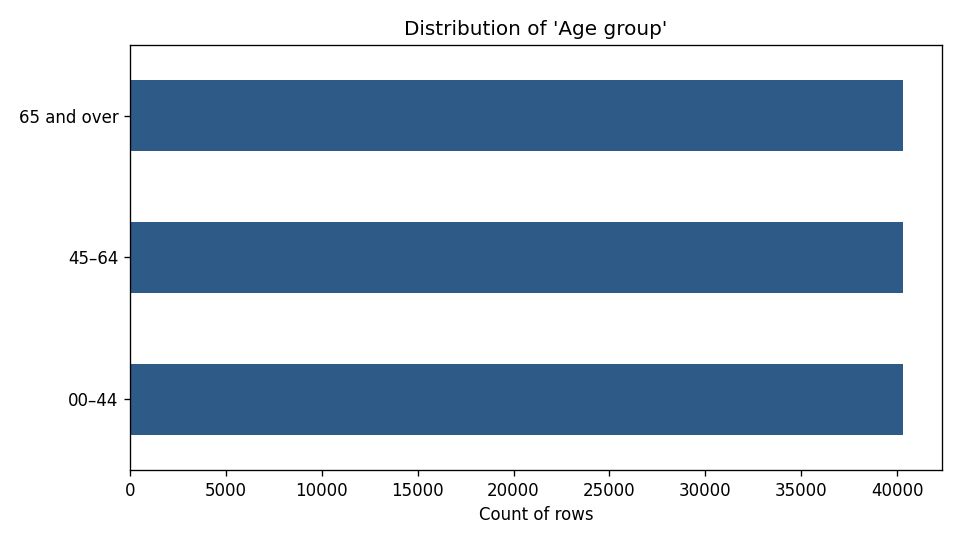

univariate_outputs/cat_country_top15.png


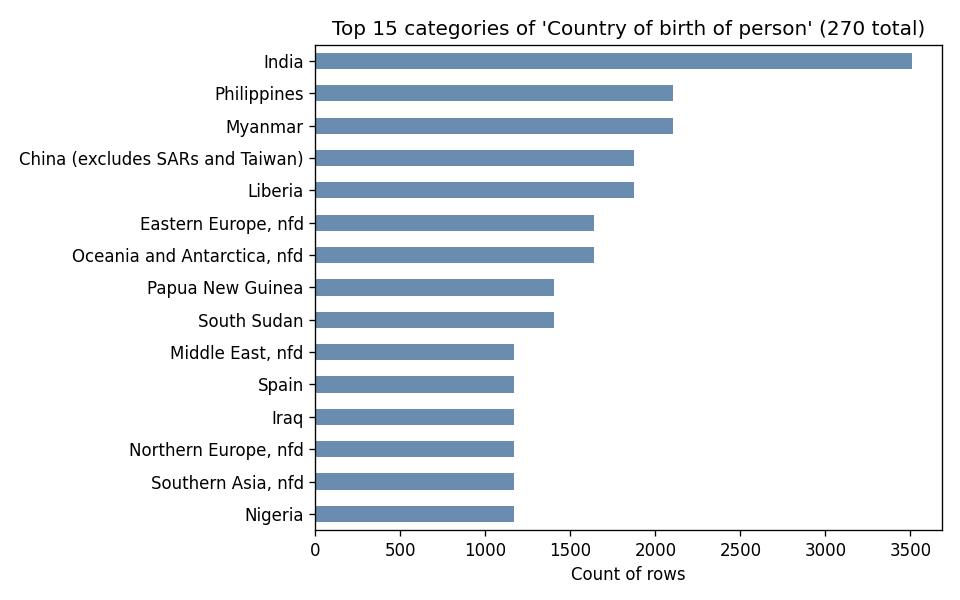

univariate_outputs/cat_english_proficiency.png


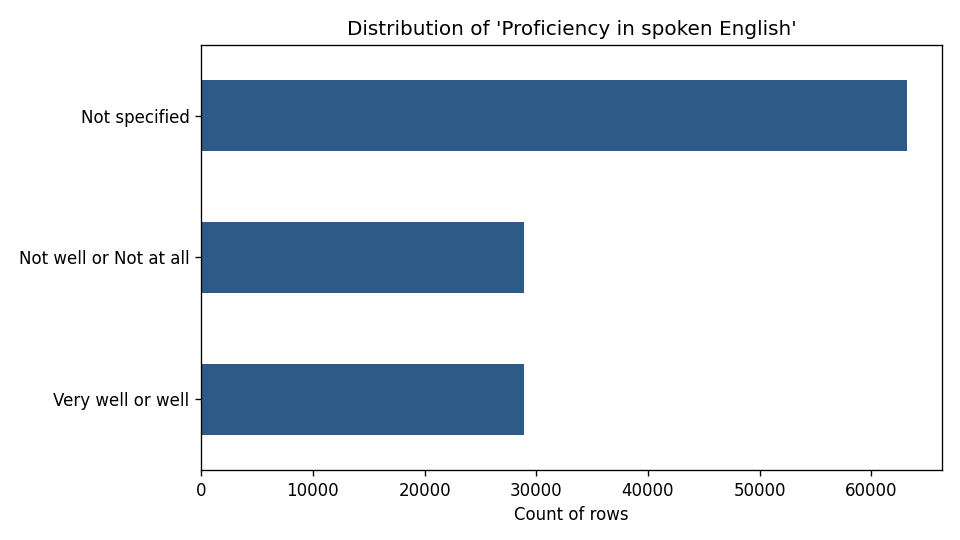

univariate_outputs/cat_language_top15.png


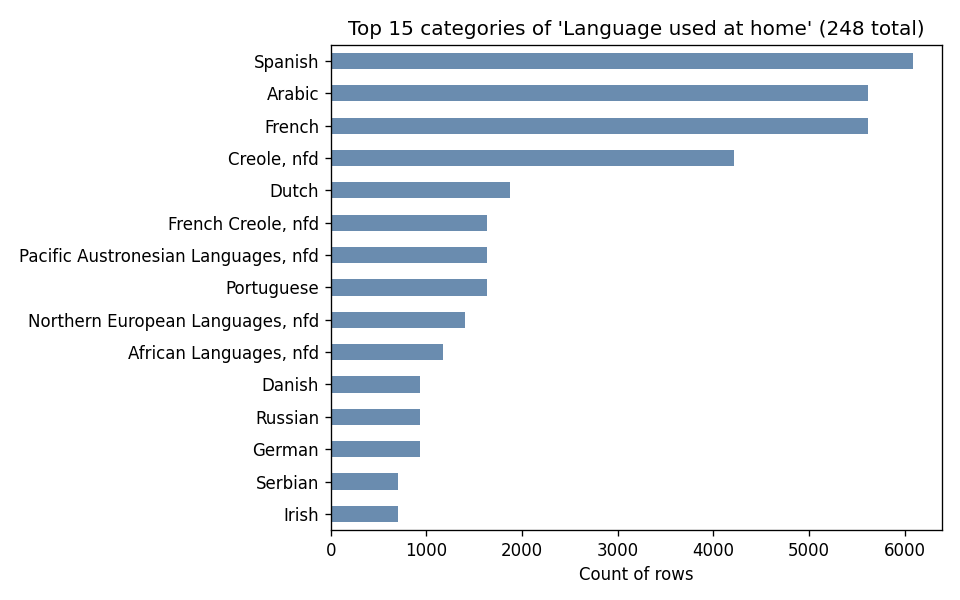

univariate_outputs/cat_lthc.png


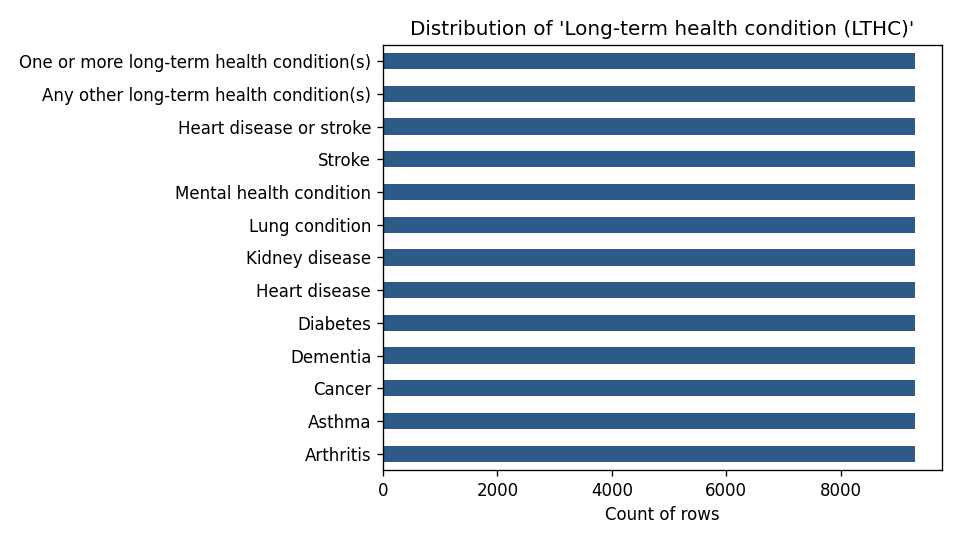

univariate_outputs/cat_region.png


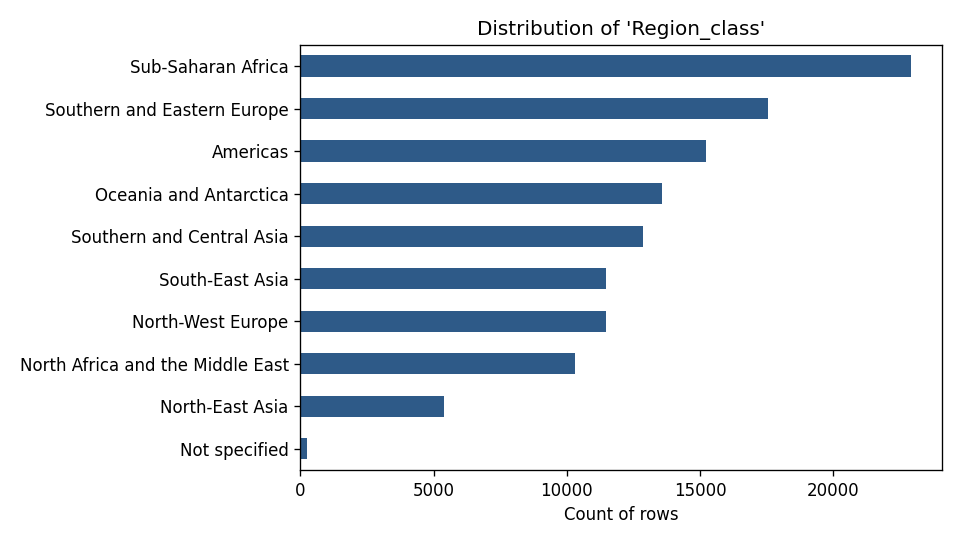

univariate_outputs/cat_sex.png


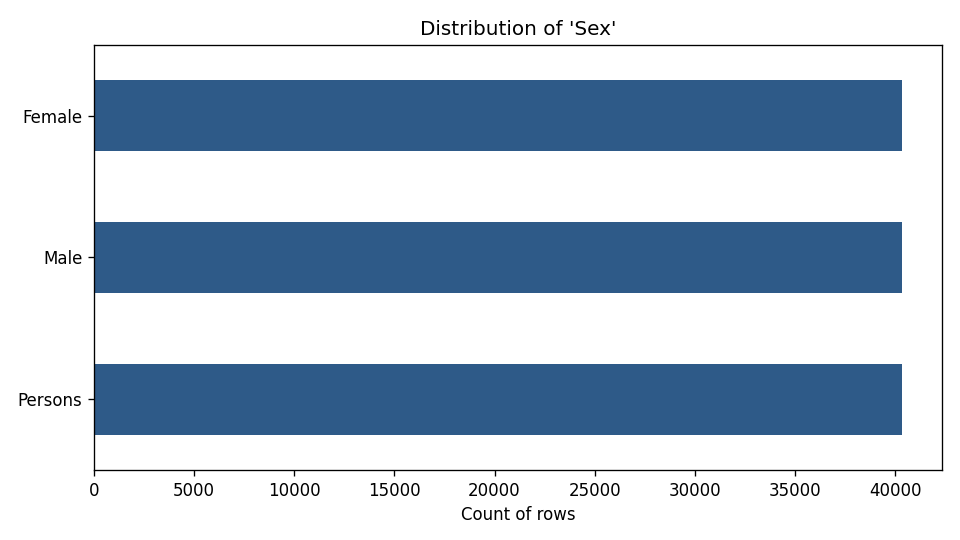

univariate_outputs/cat_subregion_top15.png


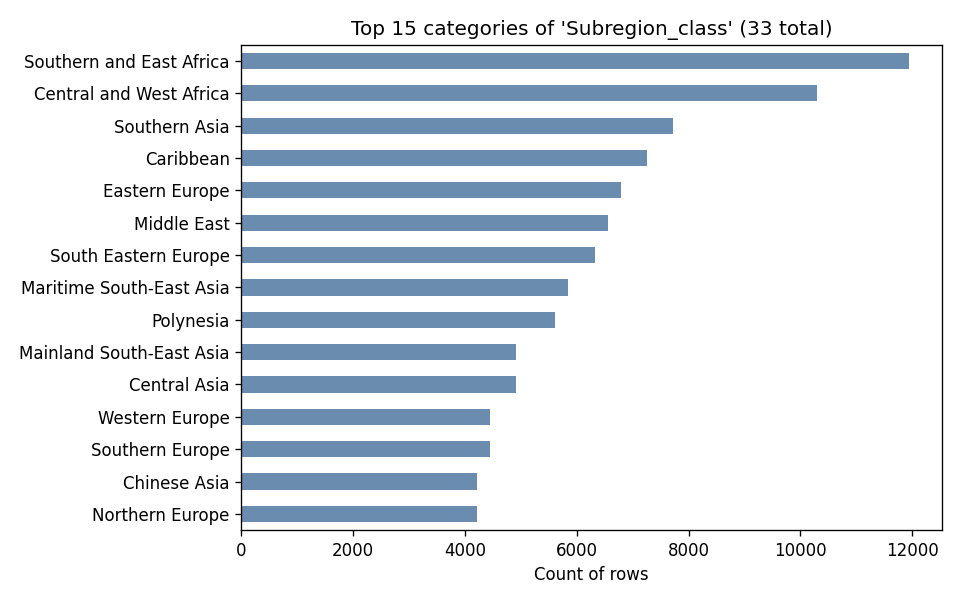

univariate_outputs/cat_years_in_australia.png


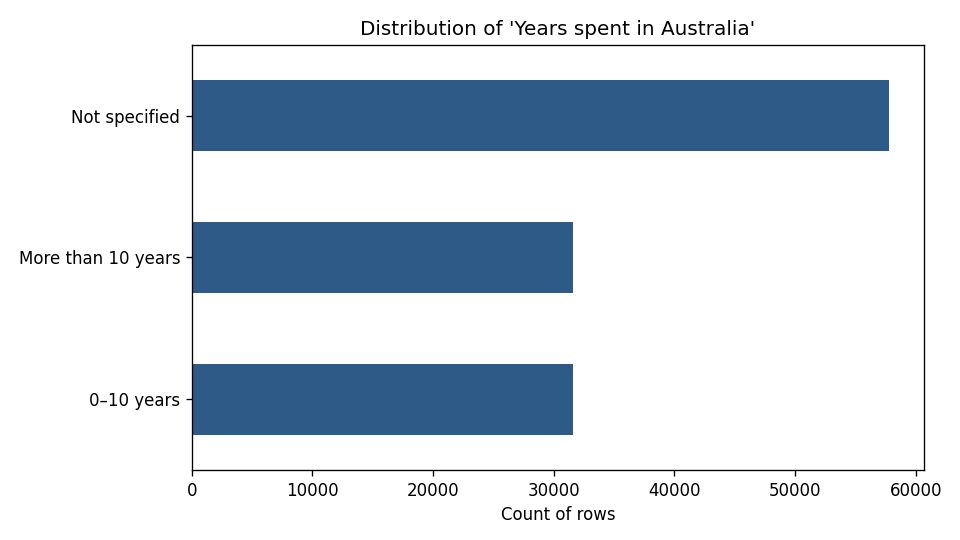

univariate_outputs/num_num_reporting.png


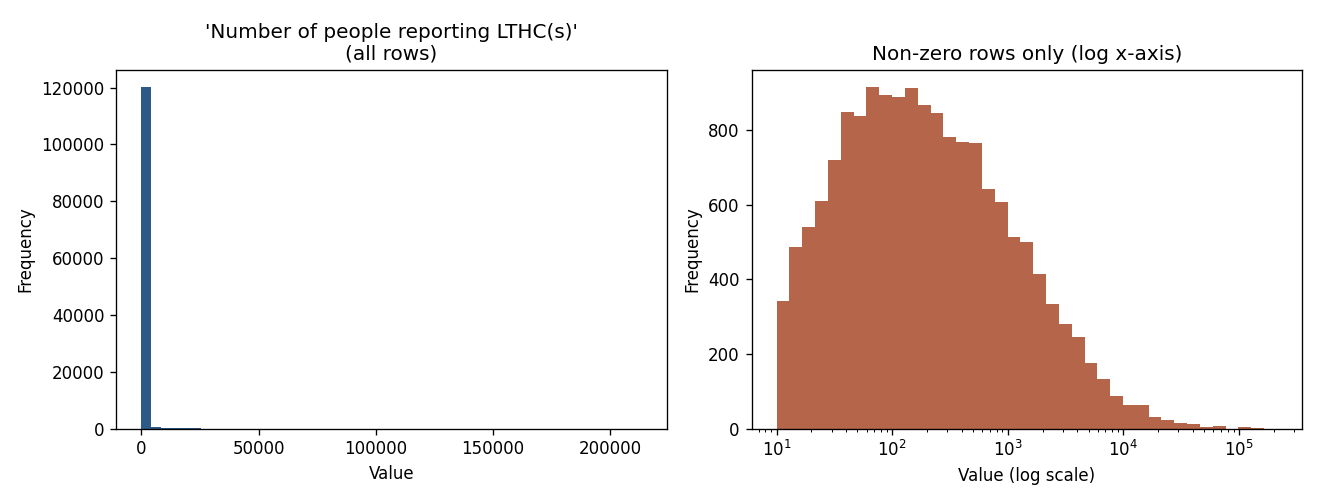

univariate_outputs/num_pct_reporting.png


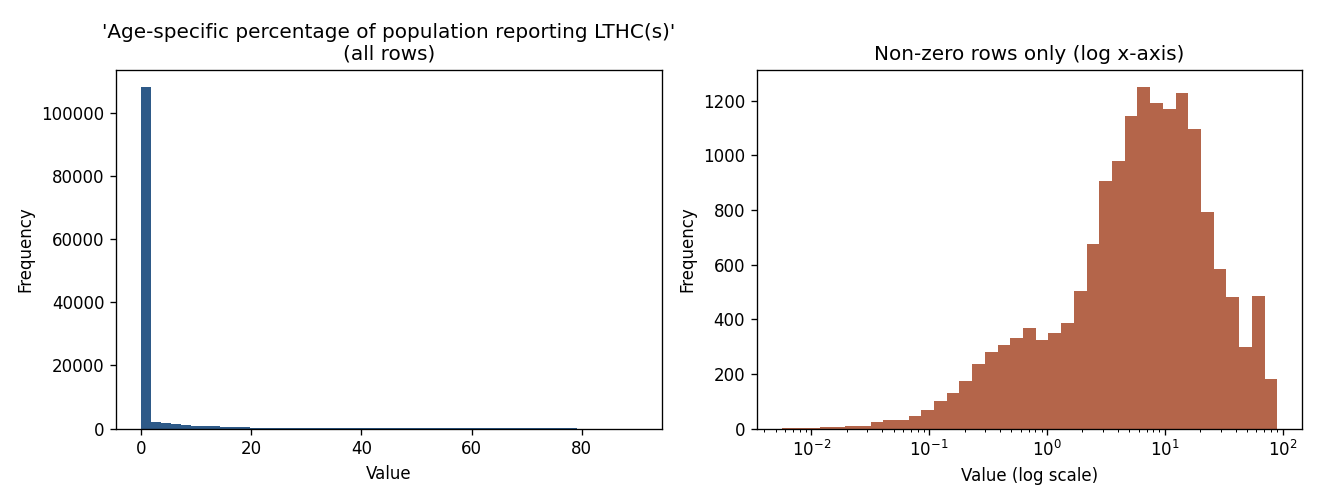

univariate_outputs/num_population.png


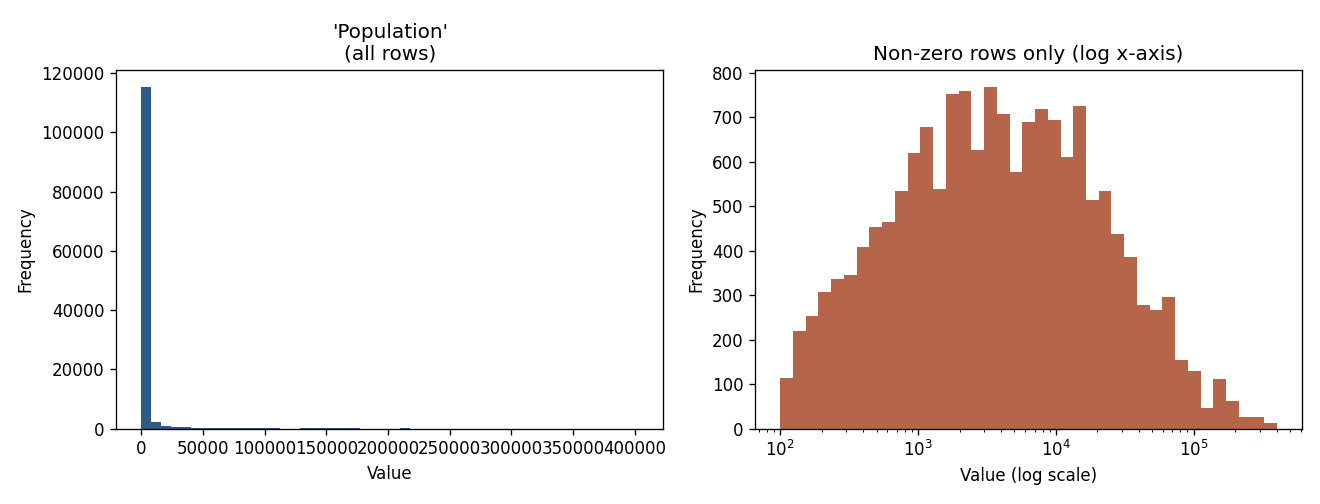

univariate_outputs/wcat_age_group.png


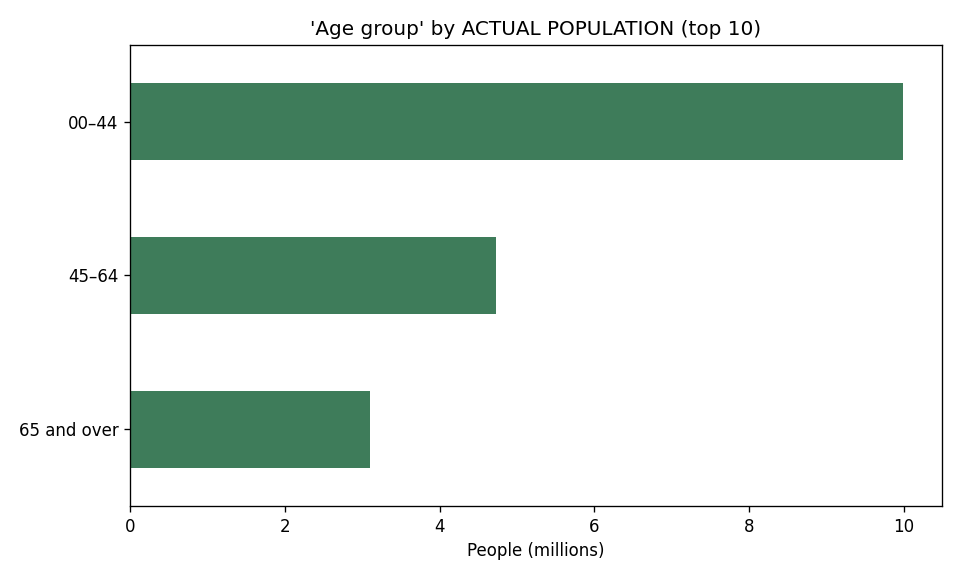

univariate_outputs/wcat_country.png


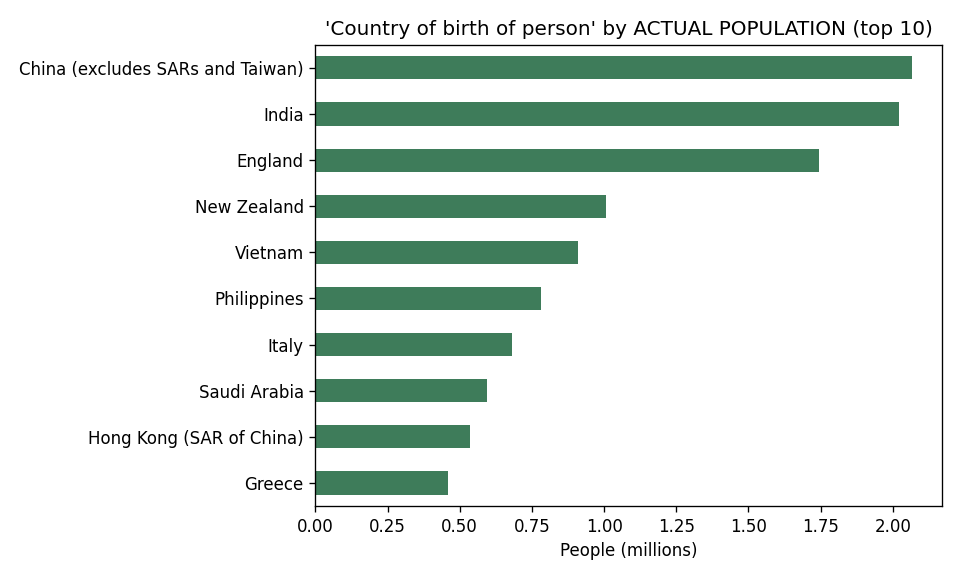

univariate_outputs/wcat_region.png


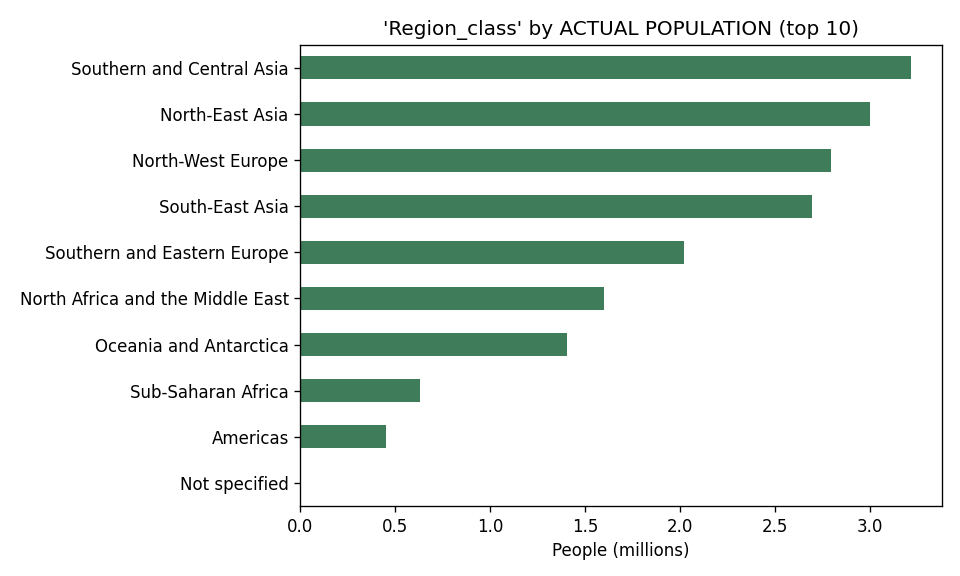

In [ ]:
import glob
from IPython.display import Image, display

summary = run_univariate_analysis(CSV_NAME)

s = summary["structure"]
print(f"Rows: {s['n_rows']:,} | Columns: {s['n_cols']} | "
      f"Populated rows (real data): {s['populated_rows']:,} | "
      f"Empty cells: {s['empty_cell_pct']}%")
print("-" * 60)

for path in sorted(glob.glob("univariate_outputs/*.png")):
    print(path)
    display(Image(path))

# Downloading all the figures

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("univariate_outputs", "zip", "univariate_outputs")
files.download("univariate_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>